Figure saved as u3_sensitivity_analysis.png


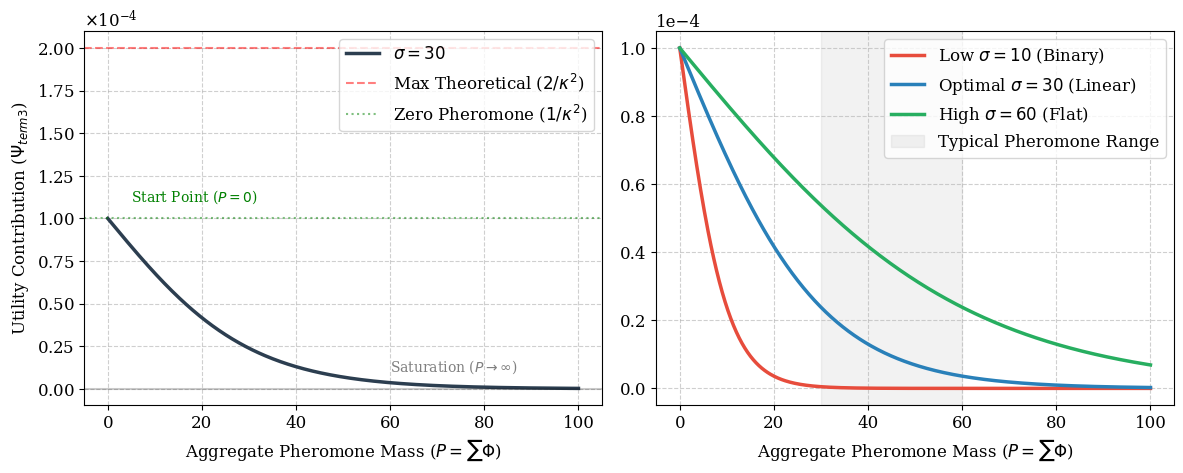

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -----------------------------
# Configuration
# -----------------------------
# Parameters based on your paper
KAPPA = 100.0   # Separation constant
SIGMA_OPT = 30.0 # Optimal sensitivity (~half max sensor mass)
R = 5
MAX_SENSOR_MASS = 2 * R * (R + 1) + 1  # ~61 for R=5

# Pheromone Sum range (P) from 0 to 100
P = np.linspace(0, 100, 500)

# The Term Function: (tanh(-P/sigma) + 1) / kappa^2
# Note: u3 = -P
def utility_term(p_mass, sigma, kappa):
    u3 = -p_mass
    numerator = np.tanh(u3 / sigma) + 1.0
    return numerator / (kappa**2)

# -----------------------------
# Plotting
# -----------------------------
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- PANEL A: Boundedness (Effect of Kappa) ---
# We plot the raw term vs Pheromone Mass
y_opt = utility_term(P, SIGMA_OPT, KAPPA)

# Plot the curve
ax1.plot(P, y_opt, color='#2c3e50', linewidth=2.5, label=f'$\\sigma={int(SIGMA_OPT)}$')

# Visual Aids for Bounds
upper_bound = 2.0 / (KAPPA**2)
mid_point = 1.0 / (KAPPA**2)
lower_bound = 0.0

ax1.axhline(y=upper_bound, color='r', linestyle='--', alpha=0.5, label='Max Theoretical ($2/\\kappa^2$)')
ax1.axhline(y=mid_point, color='g', linestyle=':', alpha=0.5, label='Zero Pheromone ($1/\\kappa^2$)')
ax1.axhline(y=lower_bound, color='k', linestyle='-', alpha=0.2)

# Annotations
ax1.text(5, mid_point + 0.00001, "Start Point ($P=0$)", fontsize=10, color='green')
ax1.text(60, 0.00001, "Saturation ($P \\to \\infty$)", fontsize=10, color='gray')

# Formatting
ax1.set_xlabel(r'Aggregate Pheromone Mass ($P = \sum \Phi$)', fontsize=12)
ax1.set_ylabel(r'Utility Contribution ($\Psi_{term3}$)', fontsize=12)
# Scientific notation for Y axis because values are small (~0.0001)
ax1.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right', frameon=True)

# --- PANEL B: Sensitivity (Effect of Sigma) ---
sigmas = [10, 30, 60]
colors = ['#e74c3c', '#2980b9', '#27ae60']
labels = [r'Low $\sigma=10$ (Binary)', r'Optimal $\sigma=30$ (Linear)', r'High $\sigma=60$ (Flat)']

for sig, col, lab in zip(sigmas, colors, labels):
    y = utility_term(P, sig, KAPPA)
    ax2.plot(P, y, color=col, linewidth=2.5, label=lab)

# Visualizing the "Discriminative Zone"
ax2.axvspan(30, 60, color='gray', alpha=0.1, label='Typical Pheromone Range')

# Formatting
ax2.set_xlabel(r'Aggregate Pheromone Mass ($P = \sum \Phi$)', fontsize=12)
# Y-axis label removed to reduce clutter, shares scale with left
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(top=0.9)

# Save
filename = "u3_sensitivity_analysis.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Figure saved as {filename}")
plt.show()

Figure saved as u3_mechanism_effect.png


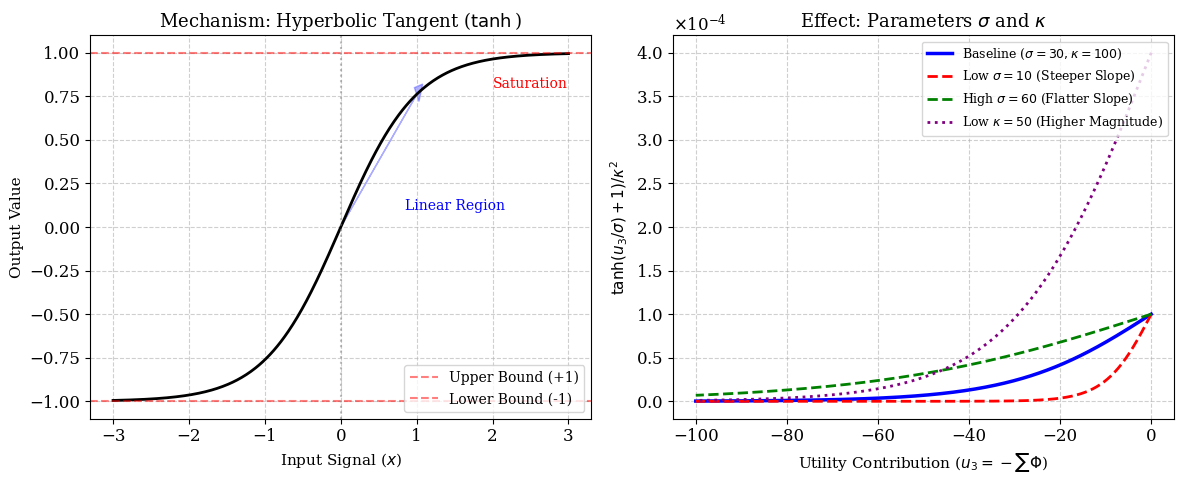

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# -----------------------------
# Configuration
# -----------------------------
# Pheromone Sum range (P)
P = np.linspace(0, 100, 500)

# -----------------------------
# Plotting
# -----------------------------
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- PANEL A: The Mechanism (Standard Tanh) ---
# We plot raw tanh to show how it saturates
x = np.linspace(-3, 3, 500)
y_tanh = np.tanh(x)

ax1.plot(x, y_tanh, color='black', linewidth=2)
ax1.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Upper Bound (+1)')
ax1.axhline(y=-1.0, color='r', linestyle='--', alpha=0.5, label='Lower Bound (-1)')
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

# Annotations
ax1.text(1.5, 0.1, "Linear Region", fontsize=10, ha='center', color='blue')
ax1.text(2.5, 0.8, "Saturation", fontsize=10, ha='center', color='red')
ax1.arrow(0, 0, 1.0, 0.76, head_width=0.1, head_length=0.1, fc='blue', ec='blue', alpha=0.3)

ax1.set_title(r"Mechanism: Hyperbolic Tangent ($\tanh$)", fontsize=13)
ax1.set_xlabel(r"Input Signal ($x$)", fontsize=11)
ax1.set_ylabel(r"Output Value", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower right', fontsize=10)


# --- PANEL B: The Effect (Sigma & Kappa) ---
# We plot the actual term: (tanh(-P/sigma) + 1) / kappa^2
def utility_term(p, sigma, kappa):
    return (np.tanh(-p / sigma) + 1.0) / (kappa**2)

# Baseline
base_sigma = 30
base_kappa = 100
y_base = utility_term(P, base_sigma, base_kappa)

# Effect of Sigma (Slope)
y_high_sigma = utility_term(P, 60, base_kappa) # Flatter slope
y_low_sigma = utility_term(P, 10, base_kappa)  # Steeper slope

# Effect of Kappa (Magnitude)
# We multiply by a factor to make it visible on the same scale, or just plot distinct curves
y_low_kappa = utility_term(P, base_sigma, 50) # Higher magnitude (1/50^2 > 1/100^2)

# Plotting
ax2.plot(-P, y_base, color='blue', linewidth=2.5, label=r'Baseline ($\sigma=30, \kappa=100$)')
ax2.plot(-P, y_low_sigma, color='red', linestyle='--', linewidth=2, label=r'Low $\sigma=10$ (Steeper Slope)')
ax2.plot(-P, y_high_sigma, color='green', linestyle='--', linewidth=2, label=r'High $\sigma=60$ (Flatter Slope)')
ax2.plot(-P, y_low_kappa, color='purple', linestyle=':', linewidth=2, label=r'Low $\kappa=50$ (Higher Magnitude)')

ax2.set_title(r"Effect: Parameters $\sigma$ and $\kappa$", fontsize=13)
# ax2.set_xlabel(r"Pheromone Sum ($\sum \Phi$)", fontsize=11)
# ax2.set_ylabel(r"Utility Contribution ($u_3$)", fontsize=11)
ax2.set_ylabel(r"$\tanh(u_3  / \sigma) + 1)/ \kappa^2 $", fontsize=11)
ax2.set_xlabel(r"Utility Contribution ($u_3 = - \sum \Phi$)", fontsize=11)

# Scientific notation for Y axis
ax2.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', fontsize=9)

# Layout adjustments
plt.tight_layout()

# Save
filename = "u3_mechanism_effect.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Figure saved as {filename}")
plt.show()

Saved convergence_spiral_gradient_v2.png


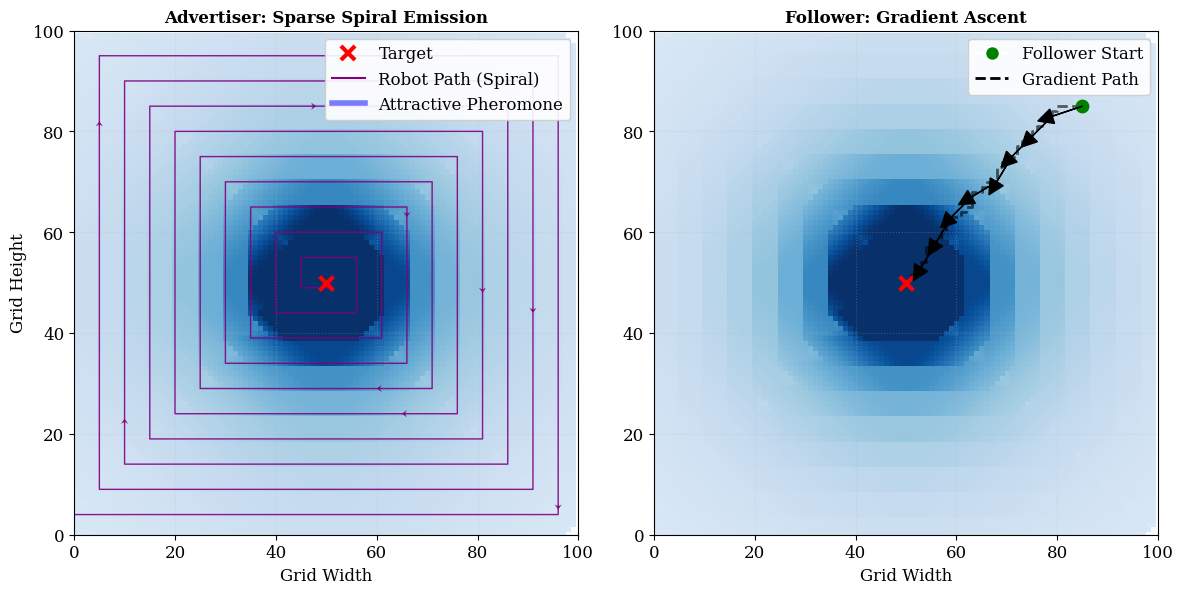

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# -----------------------------
# Simulation Logic
# -----------------------------

def sparse_spiral_generator(gap=4):
    step_length = 1
    increment = gap + 1
    direction = 0  # 0=R, 1=D, 2=L, 3=U
    moves = [(1, 0), (0, -1), (-1, 0), (0, 1)]
    while True:
        for _ in range(2):
            dx, dy = moves[direction]
            for _ in range(step_length):
                yield (dx, dy)
            direction = (direction + 1) % 4
        step_length += increment

def get_spiral_path(start_pos, steps=500):
    """Capture the actual coordinates of the robot's spiral movement."""
    x, y = start_pos
    path = [(x, y)]
    spiral = sparse_spiral_generator(gap=4)
    for _ in range(steps):
        dx, dy = next(spiral)
        x, y = x + dx, y + dy
        path.append((x, y))
    return path

def generate_pheromone_field(W, H, center, steps=500):
    pher = np.zeros((H, W))
    tx, ty = center
    x, y = center
    spiral = sparse_spiral_generator(gap=4)
    
    # Deposit at center first
    deposit(pher, x, y, tx, ty, W, H)
    
    # Run spiral
    for _ in range(steps):
        dx, dy = next(spiral)
        x, y = x + dx, y + dy
        if 0 <= x < W and 0 <= y < H:
            deposit(pher, x, y, tx, ty, W, H)
    return pher

def deposit(pher, x, y, tx, ty, W, H, r=5):
    dist = np.sqrt((x - tx)**2 + (y - ty)**2)
    signal = 10.0 / (0.1 * dist + 1e-5) # Inverse distance intensity
    
    y_min, y_max = max(0, y-r), min(H, y+r+1)
    x_min, x_max = max(0, x-r), min(W, x+r+1)
    
    for cy in range(y_min, y_max):
        for cx in range(x_min, x_max):
            if abs(cx - x) + abs(cy - y) <= r:
                pher[cy, cx] = max(pher[cy, cx], signal)

def simulate_gradient_path(pher, start_pos, target, W, H):
    path = [start_pos]
    curr = start_pos
    history = [start_pos]
    R = 5
    
    for _ in range(200): # Max steps
        cx, cy = curr
        if (cx, cy) == target or abs(cx-target[0]) + abs(cy-target[1]) <= 2:
            break
            
        # 1. Calculate Vector CoG
        vx, vy = 0.0, 0.0
        y_min, y_max = max(0, cy-R), min(H, cy+R+1)
        x_min, x_max = max(0, cx-R), min(W, cx+R+1)
        
        found_signal = False
        for dy in range(y_min, y_max):
            for dx in range(x_min, x_max):
                if abs(dx - cx) + abs(dy - cy) <= R:
                    val = pher[dy, dx]
                    if val > 1e-3:
                        found_signal = True
                        w = val ** 2
                        vx += (dx - cx) * w
                        vy += (dy - cy) * w
        
        if not found_signal: break
            
        norm = np.sqrt(vx**2 + vy**2)
        if norm > 0: vx, vy = vx/norm, vy/norm
            
        # 2. Choose Neighbor
        best_score = -np.inf
        best_n = None
        neighbors = [(0,1), (0,-1), (1,0), (-1,0)]
        for dx, dy in neighbors:
            nx, ny = cx + dx, cy + dy
            if 0 <= nx < W and 0 <= ny < H:
                if (nx, ny) in history[-4:]: continue
                score = (dx * vx + dy * vy) + 0.1 * pher[ny, nx]
                if score > best_score:
                    best_score = score
                    best_n = (nx, ny)
        
        if best_n:
            path.append(best_n)
            history.append(best_n)
            curr = best_n
        else:
            break
    return path

# -----------------------------
# Plotting
# -----------------------------
W, H = 100, 100
target = (50, 50)
steps = 3000

# Generate Data
pher = generate_pheromone_field(W, H, target, steps=steps)
advertiser_path = get_spiral_path(target, steps=steps) # Get the coordinates
follower_path = simulate_gradient_path(pher, (85, 85), target, W, H)

# Setup Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
plt.rcParams.update({'font.family': 'serif', 'font.size': 12})

# --- PANEL A: Advertiser (Spiral) ---
# 1. Plot Pheromone Field (Background)
im = ax1.imshow(pher, origin='lower', cmap='Blues', vmin=0, vmax=10)

# 2. Plot Robot Path (Yellow Line)
# Filter path to stay within bounds for plotting
adv_x, adv_y = zip(*[(x, y) for x, y in advertiser_path if 0 <= x < W and 0 <= y < H])
ax1.plot(adv_x, adv_y, color='purple', linewidth=1.0, alpha=0.9, label='Advertiser Path')
arrow_spacing = max(1, len(adv_x) // 10)  # Show ~20 arrows along the path
for i in range(0, len(adv_x) - 1, arrow_spacing):
    dx = adv_x[i + 1] - adv_x[i]
    dy = adv_y[i + 1] - adv_y[i]
    ax1.quiver(adv_x[i], adv_y[i], dx, dy, 
               angles='xy', scale_units='xy', scale=1,
               color='purple', alpha=0.9, width=0.01, headwidth=10, headlength=7)

# 3. Plot Target
ax1.scatter([target[0]], [target[1]], c='red', marker='x', s=100, linewidth=3, label='Target', zorder=10)

# Formatting
ax1.set_xlim(0, 100); ax1.set_ylim(0, 100); ax1.set_aspect('equal')
ax1.set_xlabel('Grid Width'); ax1.set_ylabel('Grid Height')
ax1.grid(True, linestyle=':', alpha=0.3)
ax1.set_title("Advertiser: Sparse Spiral Emission", fontsize=12, fontweight='bold')

# Custom Legend for Panel A
# We need to manually add the Pheromone Field to the legend since imshow doesn't support labels directly
custom_lines = [
    Line2D([0], [0], color='red', marker='x', linestyle='None', markersize=10, markeredgewidth=3),
    Line2D([0], [0], color='purple', linewidth=1.5),
    Line2D([0], [0], color='blue', alpha=0.5, linewidth=4) # Proxy for blue field
]
ax1.legend(custom_lines, ['Target', 'Robot Path (Spiral)', 'Attractive Pheromone'], loc='upper right', framealpha=0.9)


# --- PANEL B: Follower (Gradient) ---
ax2.imshow(pher, origin='lower', cmap='Blues', vmin=0, vmax=10)
ax2.scatter([target[0]], [target[1]], c='red', marker='x', s=100, linewidth=3, zorder=10)

# Plot Follower Path
px, py = zip(*follower_path)
ax2.plot(px, py, c='black', linewidth=2, linestyle='--', alpha=0.6, label='Follower Gradient Path')
# Draw arrows
step = 8
for i in range(0, len(follower_path)-step, step):
    p1 = follower_path[i]
    p2 = follower_path[i+step]
    ax2.arrow(p1[0], p1[1], p2[0]-p1[0], p2[1]-p1[1], head_width=3, head_length=3, fc='k', ec='k', zorder=20)

ax2.scatter([follower_path[0][0]], [follower_path[0][1]], c='green', s=80, label='Follower Start', zorder=15)
ax2.set_xlim(0, 100); ax2.set_ylim(0, 100); ax2.set_aspect('equal')
ax2.set_xlabel('Grid Width')
ax2.grid(True, linestyle=':', alpha=0.3)
ax2.set_title("Follower: Gradient Ascent", fontsize=12, fontweight='bold')

# Custom Legend for Panel B
custom_lines_b = [
    # Line2D([0], [0], color='red', marker='x', linestyle='None', markersize=10, markeredgewidth=3),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2)
]
ax2.legend(custom_lines_b, ['Follower Start', 'Gradient Path'], loc='upper right', framealpha=0.9)

plt.tight_layout()
filename = "convergence_spiral_gradient_v2.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Saved {filename}")
plt.show()